
# HITO 2 – Análisis de Datos y Formulación del Problema


Índice:

- Análisis Exploratorio de los Datos (EDA)
- Definición del problema
- Formulación de métricas


### 1. Carga de Datos y Exploración Inicial

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
sns.set_theme(style="whitegrid")#
plt.rcParams['figure.figsize'] = (10, 6)#   

In [4]:

df = pd.read_csv("../data/securecarx_dataset.csv")
df.head()

,SEX,INSR_BEGIN,INSR_END,EFFECTIVE_YR,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID
0,0,08-AUG-17,07-AUG-18,08,1202,519755.22,5097.83,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
1,0,08-AUG-16,07-AUG-17,08,1202,519755.22,6556.52,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
2,0,08-AUG-15,07-AUG-16,08,1202,519755.22,6556.52,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
3,0,08-AUG-14,07-AUG-15,08,1202,519755.22,5102.83,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
4,0,08-AUG-17,07-AUG-18,08,1202,1400000.00,13304.87,5000029901,2010.0,4.0,7.0,Pick-up,2494.0,TOYOTA,Own Goods,NaN


In [4]:
print("Dimension:", df.shape)#dimensiones del dataset

Dimension: (508499, 16)


In [5]:
print(df.dtypes)#devuelve el tipo de dato de cada columna

SEX                    int64
INSR_BEGIN            object
INSR_END              object
EFFECTIVE_YR          object
INSR_TYPE              int64
INSURED_VALUE        float64
PREMIUM              float64
OBJECT_ID              int64
PROD_YEAR            float64
SEATS_NUM            float64
CARRYING_CAPACITY    float64
TYPE_VEHICLE          object
CCM_TON              float64
MAKE                  object
USAGE                 object
CLAIM_PAID           float64
dtype: object


In [ ]:
#identificar los valores nulos en el dataset
df.isnull().sum() #cuenta el numero de nulos, isnull crea un df temporal de booleanos, y sum() cuenta los True (nulos) por columna

SEX                       0
INSR_BEGIN                0
INSR_END                  0
EFFECTIVE_YR              3
INSR_TYPE                 0
INSURED_VALUE             0
PREMIUM                  13
OBJECT_ID                 0
PROD_YEAR                63
SEATS_NUM                95
CARRYING_CAPACITY    116834
TYPE_VEHICLE              0
CCM_TON                   6
MAKE                      5
USAGE                     0
CLAIM_PAID           470727
dtype: int64

### 2. ANÁLISIS EXPLORATORIO (EDA)

In [7]:
df_claim = df[df['CLAIM_PAID'] > 0] #nos quedamos con los registros donde se ha pagado una indemnización
df_claim.describe()#devuelve estadísticas descriptivas de las columnas numéricas 

,SEX,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,CCM_TON,CLAIM_PAID
count,37737.000000,37737.000000,3.773700e+04,37737.000000,3.773700e+04,37736.000000,37734.000000,28274.000000,37737.000000,3.773700e+04
mean,0.433712,1201.739168,1.036063e+06,15586.417171,5.000510e+09,2007.727263,10.676737,390.371534,4167.633694,2.432834e+05
std,0.617145,0.439275,9.219454e+05,13630.980164,3.396409e+05,8.057240,22.627156,2968.923307,3412.672398,1.082408e+06
min,0.000000,1201.000000,0.000000e+00,0.000000,5.000018e+09,1950.000000,0.000000,0.000000,0.000000,5.000000e+00
25%,0.000000,1201.000000,3.500000e+05,5271.830000,5.000167e+09,2005.000000,2.000000,0.000000,1998.000000,1.490298e+04
50%,0.000000,1202.000000,8.000000e+05,11225.550000,5.000538e+09,2010.000000,4.000000,7.000000,2986.000000,3.681825e+04
75%,1.000000,1202.000000,1.500000e+06,22416.630000,5.000778e+09,2014.000000,8.000000,60.000000,4570.000000,1.354915e+05
max,2.000000,1204.000000,1.966105e+07,183818.920000,5.001323e+09,2018.000000,161.000000,47000.000000,19980.000000,7.924714e+07


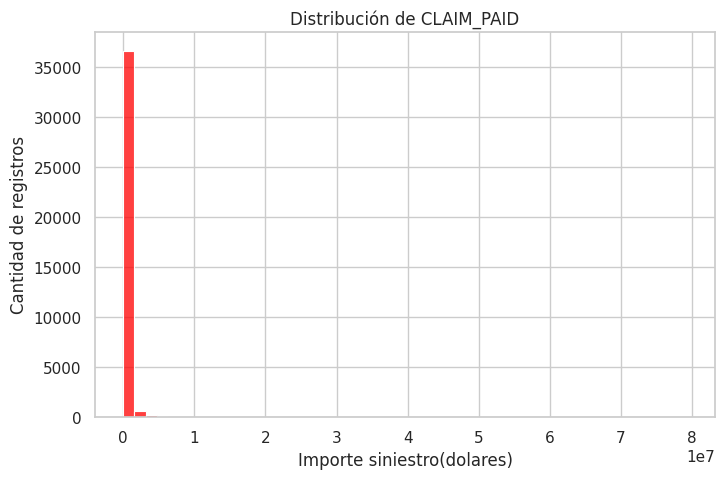

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df_claim['CLAIM_PAID'], bins=50, color='red')
plt.title('Distribución de CLAIM_PAID')
plt.xlabel('Importe siniestro(dolares)')
plt.ylabel('Cantidad de registros')
plt.show()


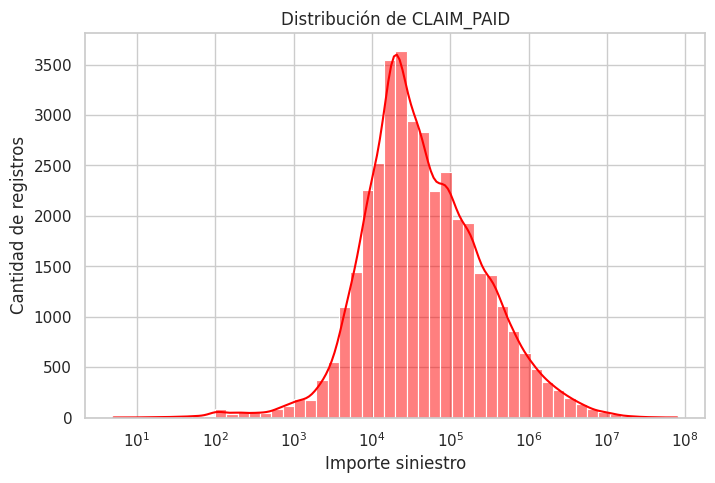

In [9]:
#Grafica en escala logaritmica
plt.figure(figsize=(8, 5))
sns.histplot(df_claim['CLAIM_PAID'], bins=50, kde=True,color='red',log_scale=True)
plt.title('Distribución de CLAIM_PAID')
plt.xlabel('Importe siniestro')
plt.ylabel('Cantidad de registros')
plt.show()



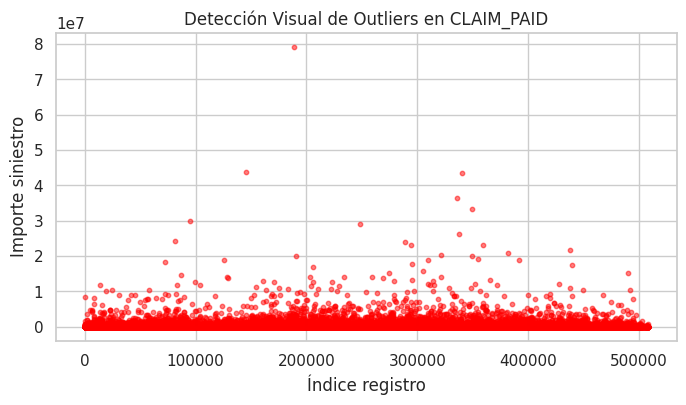

In [10]:

#Grafica de dispersion
plt.figure(figsize=(8, 4))
plt.scatter(df_claim.index, df_claim['CLAIM_PAID'], alpha=0.5, color='red', s=10)
plt.title('Detección Visual de Outliers en CLAIM_PAID')
plt.xlabel('Índice registro')#para evitar amontonamiento
plt.ylabel('Importe siniestro')
plt.show()

In [11]:
# Seleccionamos las variables numéricas que tienen sentido financiero
columnas_validas = ['INSURED_VALUE', 'PREMIUM', 'CLAIM_PAID']

# Calculamos la matriz de correlación
matriz_correlacion = df_claim[columnas_validas].corr()

# Mostramos los números en pantalla
print(matriz_correlacion)

               INSURED_VALUE   PREMIUM  CLAIM_PAID
INSURED_VALUE       1.000000  0.703486    0.084535
PREMIUM             0.703486  1.000000    0.135248
CLAIM_PAID          0.084535  0.135248    1.000000


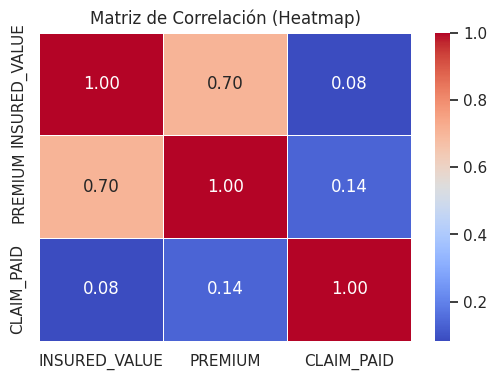

In [12]:
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación (Heatmap)')
plt.show()

/tmp/ipykernel_6037/2782051968.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_claim['CLAIM_PAID_LOG'] = np.log1p(df_claim['CLAIM_PAID'])
/tmp/ipykernel_6037/2782051968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TYPE_VEHICLE', y='CLAIM_PAID_LOG', data=df_claim, palette='Set2')


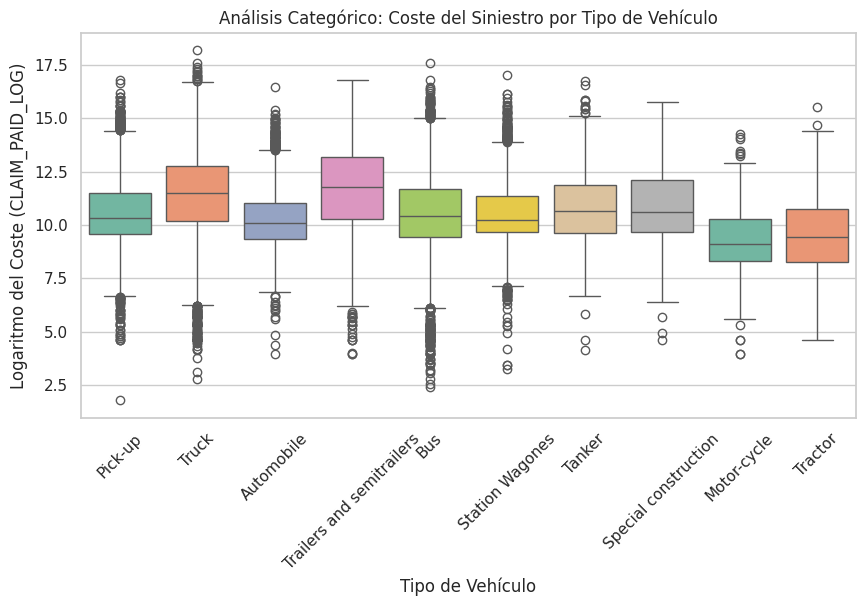

In [13]:
# Creamos la columna del logaritmo temporalmente para que el gráfico se vea bien
df_claim['CLAIM_PAID_LOG'] = np.log1p(df_claim['CLAIM_PAID'])

# Dibujamos el Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x='TYPE_VEHICLE', y='CLAIM_PAID_LOG', data=df_claim, palette='Set2')
plt.title('Análisis Categórico: Coste del Siniestro por Tipo de Vehículo')
plt.xlabel('Tipo de Vehículo')
plt.ylabel('Logaritmo del Coste (CLAIM_PAID_LOG)')
plt.xticks(rotation=45)
plt.show()

### 3. Limpieza de Datos

In [ ]:
# Elimina duplicados exactos
df = df.drop_duplicates().copy() #elimina filas duplicadas exactas y mantiene el primero por defecto, y crea una copia del dataframe
df = df.drop_duplicates(subset=['OBJECT_ID', 'INSR_BEGIN', 'INSR_END'], keep='first').copy() # Elimina filas duplicadas según el coche y periodo de cobertura, keep = first mantiene solo la primera.

In [ ]:
# Conversión a tipo dato fecha
df['INSR_BEGIN'] = pd.to_datetime(df['INSR_BEGIN'], errors='coerce', format='mixed')# Convierte a fecha, coerce transforma textos de fechas invalidos en nuloss y mixed maneja formatos mixtos de fecha 
df['INSR_END'] = pd.to_datetime(df['INSR_END'], errors='coerce', format='mixed')
#  Consistencia lógica de fechas
df = df.dropna(subset=['INSR_BEGIN', 'INSR_END']).copy() # Elimina filas donde falte la fecha de inicio o fin o ambas, y crea una copia del dataframe
df = df[df['INSR_BEGIN'] <= df['INSR_END']].copy()#regla de negocio fecha inicio debe ser menor o igual a fecha fin
#Acotar fechas lógicas (A partir del año 2000)
df = df[df['INSR_BEGIN'] >= '2000-01-01'].copy()
# Crear variable de duración (importante para el Hito 3)
df['DURATION'] = (df['INSR_END'] - df['INSR_BEGIN']).dt.days # devuelve la diferencia en días entre las fechas de inicio y fin de cobertura mediante dt.days


In [16]:
# Filtrar siniestros reales (Eliminar nulos NAN y ceros en la variable objetivo)
df_clean = df[df['CLAIM_PAID'] > 0].copy()

In [17]:
# Eliminar columnas irrelevantes
columnas_a_eliminar = ['OBJECT_ID', 'EFFECTIVE_YR', 'INSR_BEGIN', 'INSR_END']
df_clean = df_clean.drop(columns=columnas_a_eliminar)

In [18]:
# Limpieza de nulos 
df_clean = df_clean.dropna(subset=['PROD_YEAR', 'SEATS_NUM', 'CCM_TON', 'MAKE'])
# Limpieza de ceros
df_clean = df_clean[df_clean['INSURED_VALUE'] > 0]
df_clean = df_clean[df_clean['PREMIUM'] > 0]
df_clean = df_clean[df_clean['SEATS_NUM'] > 0]
df_clean = df_clean[df_clean['CCM_TON'] > 0]

In [19]:
# Tratamiento específico para CARRYING_CAPACITY (Rellenar coches con 0)
df_clean['CARRYING_CAPACITY'] = df_clean['CARRYING_CAPACITY'].fillna(0)

In [20]:
# 6. Acotar rangos que se considera validos
df_clean = df_clean[df_clean['PROD_YEAR'] >= 2000]
df_clean = df_clean[df_clean['SEATS_NUM'] <= 70]

In [21]:
# Elimina fraudes o errores de datos donde la indemnización supera el valor del coche (+10% margen)
df_clean = df_clean[df_clean['CLAIM_PAID'] <= (df_clean['INSURED_VALUE'] * 1.1)].copy()

In [22]:
# Regla B: Estadística (IQR)
# Identificación y eliminación de outliers mediante IQR:
# 1. Calcula los cuartiles 25% (Q1) y 75% (Q3) del coste.
# 2. Define el límite superior tolerado (Q3 + 1.5 * IQR).
# 3. Elimina los siniestros extremadamente caros (como el caso de 79M) para limpiar los datos.
Q1 = df_clean['CLAIM_PAID'].quantile(0.25)
Q3 = df_clean['CLAIM_PAID'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
df_clean = df_clean[df_clean['CLAIM_PAID'] <= limite_superior].copy()

In [23]:
# Transformación Logarítmica para estabilizar la escala en el Hito 3
df_clean['CLAIM_PAID_LOG'] = np.log1p(df_clean['CLAIM_PAID'])

In [24]:
#  Guardar el archivo final listo para entrenar el Random Forest
df_clean.to_csv('../data/securecarx_dataset_clean.csv', index=False)
print("--- PROCESO DE LIMPIEZA COMPLETADO ---")

--- PROCESO DE LIMPIEZA COMPLETADO ---


In [25]:
#Prueba
print("Dimension:", df_clean.shape)#dimensiones del dataset
df_clean.isnull().sum()

Dimension: (22886, 14)


SEX                  0
INSR_TYPE            0
INSURED_VALUE        0
PREMIUM              0
PROD_YEAR            0
SEATS_NUM            0
CARRYING_CAPACITY    0
TYPE_VEHICLE         0
CCM_TON              0
MAKE                 0
USAGE                0
CLAIM_PAID           0
DURATION             0
CLAIM_PAID_LOG       0
dtype: int64

In [26]:
# Cargamos el dataset limpio para asegurarnos de que se lee bien
df_final = pd.read_csv("../data/securecarx_dataset_clean.csv")

print(f"Estructura final del dataset: {df_final.shape[0]} filas y {df_final.shape[1]} columnas.")
print("\nConteo de nulos por columna:")
print(df_final.isnull().sum())

Estructura final del dataset: 22886 filas y 14 columnas.

Conteo de nulos por columna:
SEX                  0
INSR_TYPE            0
INSURED_VALUE        0
PREMIUM              0
PROD_YEAR            0
SEATS_NUM            0
CARRYING_CAPACITY    0
TYPE_VEHICLE         0
CCM_TON              0
MAKE                 0
USAGE                0
CLAIM_PAID           0
DURATION             0
CLAIM_PAID_LOG       0
dtype: int64


In [27]:
print(df_final[['CLAIM_PAID', 'CLAIM_PAID_LOG']].describe())

          CLAIM_PAID  CLAIM_PAID_LOG
count   22886.000000    22886.000000
mean    58748.004158       10.333092
std     65744.160406        1.261732
min         5.000000        1.791759
25%     14375.000000        9.573315
50%     29927.975000       10.306582
75%     80559.017500       11.296758
max    294662.540000       12.593589


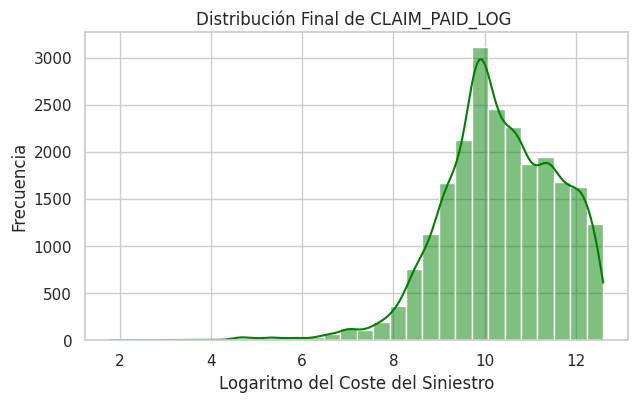

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
#El eje X muestra el dinero de las indemnizaciones, pero transformado a escala logarítmica
plt.figure(figsize=(7, 4))
sns.histplot(df_final['CLAIM_PAID_LOG'], bins=30, kde=True, color='green')
plt.title('Distribución Final de CLAIM_PAID_LOG ')
plt.xlabel('Logaritmo del Coste del Siniestro')
plt.ylabel('Frecuencia')
plt.show()

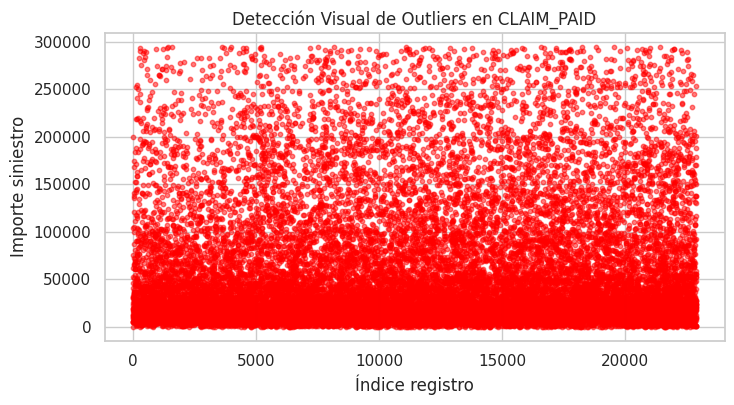

In [29]:

#Grafica de dispersion
plt.figure(figsize=(8, 4))
plt.scatter(df_final.index, df_final['CLAIM_PAID'], alpha=0.5, color='red', s=10)
plt.title('Detección Visual de Outliers en CLAIM_PAID')
plt.xlabel('Índice registro')#para evitar amontonamiento
plt.ylabel('Importe siniestro')
plt.show()

               INSURED_VALUE   PREMIUM  CLAIM_PAID
INSURED_VALUE       1.000000  0.669511    0.029286
PREMIUM             0.669511  1.000000    0.172804
CLAIM_PAID          0.029286  0.172804    1.000000


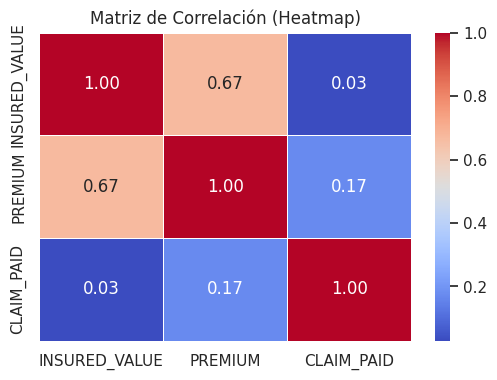

In [30]:
# Seleccionamos las variables numéricas que tienen sentido financiero
columnas_validas = ['INSURED_VALUE', 'PREMIUM', 'CLAIM_PAID']

# Calculamos la matriz de correlación
matriz_correlacion = df_final[columnas_validas].corr()

# Mostramos los números en pantalla
print(matriz_correlacion)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación (Heatmap)')
plt.show()


# HITO 3 


Índice:

- Modelado, experimentación y validación
- Selección del modelo de machine learning
- Diseño de experimentos, ajuste de hiperparámetros
- Análisis de resultados. Validación del modelo propuesto

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

In [32]:
df_ml = pd.read_csv("../data/securecarx_dataset_clean.csv")
print(f"Dataset cargado correctamente. Registros disponibles para entrenar: {df_ml.shape[0]}")
print(df_ml.dtypes)

Dataset cargado correctamente. Registros disponibles para entrenar: 22886
SEX                    int64
INSR_TYPE              int64
INSURED_VALUE        float64
PREMIUM              float64
PROD_YEAR            float64
SEATS_NUM            float64
CARRYING_CAPACITY    float64
TYPE_VEHICLE          object
CCM_TON              float64
MAKE                  object
USAGE                 object
CLAIM_PAID           float64
DURATION               int64
CLAIM_PAID_LOG       float64
dtype: object


In [33]:
# 1. Pasamos las variables numéricas categóricas a texto para que get_dummies las procese
df_ml['SEX'] = df_ml['SEX'].astype(str)
df_ml['INSR_TYPE'] = df_ml['INSR_TYPE'].astype(str)

### 1: Separaración de Variables X e Y
Sacas la variable que quieres predecir (y) y dejas el resto en el bloque de características (X).

In [34]:
# 1. Separamos las características (X) y la variable objetivo (y)
# Quitamos ambas versiones de CLAIM_PAID de las características X
X = df_ml.drop(columns=['CLAIM_PAID', 'CLAIM_PAID_LOG'])
# Elegimos qué versión queremos predecir (normalmente se entrena con el LOG)
y = df_ml['CLAIM_PAID_LOG']

### 2: Codificación de Texto (One-Hot Encoding)
Transformas las columnas de texto de X en columnas de ceros y unos.

In [35]:

# Conversión de variables categóricas y de texto a numéricas (One-Hot Encoding)
# Esto crea columnas binarias (0 y 1) para cada categoría
columnas_categoricas = ['SEX', 'INSR_TYPE', 'TYPE_VEHICLE', 'MAKE', 'USAGE']
X_encoded = pd.get_dummies(X, columns=columnas_categoricas, drop_first=True, dtype=int)

print("--- PREPROCESAMIENTO COMPLETADO ---")
print(f"Columnas originales en X: {X.shape[1]}")
print(f"Nuevas columnas en X tras One-Hot Encoding: {X_encoded.shape[1]}")
print(f"Total de nulos en el bloque de entrenamiento: {X_encoded.isnull().sum().sum()}")


--- PREPROCESAMIENTO COMPLETADO ---
Columnas originales en X: 12
Nuevas columnas en X tras One-Hot Encoding: 208
Total de nulos en el bloque de entrenamiento: 0


### 3. División en Entrenamiento (Train) y Prueba (Test)
Dividir el dataset (normalmente 80% para entrenar y 20% para test).

In [36]:
# Dividimos el dataset (80% train, 20% test)
# random_state=42 asegura que la división siempre sea la misma al ejecutar el notebook
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42
)

print("--- DIVISIÓN DE DATOS COMPLETADA ---")
print(f"Registros totales para Entrenamiento (X_train): {X_train.shape[0]} filas")
print(f"Registros totales para Prueba (X_test): {X_test.shape[0]} filas")
print(f"Número total de características (columnas) que procesará la IA: {X_train.shape[1]}")

--- DIVISIÓN DE DATOS COMPLETADA ---
Registros totales para Entrenamiento (X_train): 18308 filas
Registros totales para Prueba (X_test): 4578 filas
Número total de características (columnas) que procesará la IA: 208


### 4. Entrenamiento del Random Forest

In [37]:
# Definimos la rejilla con las opciones que queremos probar matemáticamente
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [7, 15],
    'min_samples_split': [5],
    'min_samples_leaf': [1, 10]
}

# Configuras el buscador automático con Validación Cruzada (cv=5)
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1  # Usa todos los núcleos de tu Ryzen 9
)

# Entrenamos: El sistema busca internamente la mejor combinación
grid_search.fit(X_train, y_train)

# Extraemos el modelo ganador y lo guardamos exactamente con tu nombre de variable
modelo_rf_ajustado = grid_search.best_estimator_

print("=== MEJORES HIPERPARAMETROS ENCONTRADOS ===")
print(grid_search.best_params_)
print("-" * 45)

# Nuevas predicciones
y_pred_train_log2 = modelo_rf_ajustado.predict(X_train)
y_pred_test_log2 = modelo_rf_ajustado.predict(X_test)

# Calculamos métricas en escala logarítmica
rmse_train_log2 = np.sqrt(mean_squared_error(y_train, y_pred_train_log2))
r2_train_log2 = r2_score(y_train, y_pred_train_log2)

rmse_test_log2 = np.sqrt(mean_squared_error(y_test, y_pred_test_log2))
r2_test_log2 = r2_score(y_test, y_pred_test_log2)

print("=== EVALUACIÓN CON MODELO REGULARIZADO ===")
print(f"Métricas en ENTRENAMIENTO (Train Log):")
print(f"  - RMSE: {rmse_train_log2:.4f}")
print(f"  - R²:   {r2_train_log2:.4f} ({r2_train_log2*100:.1f}%)")
print("-" * 35)
print(f"Métricas en VALIDACIÓN (Test Log):")
print(f"  - RMSE: {rmse_test_log2:.4f}")
print(f"  - R²:   {r2_test_log2:.4f} ({r2_test_log2*100:.1f}%)")

=== MEJORES HIPERPARAMETROS ENCONTRADOS ===
{'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 100}
---------------------------------------------
=== EVALUACIÓN CON MODELO REGULARIZADO ===
Métricas en ENTRENAMIENTO (Train Log):
  - RMSE: 1.1922
  - R²:   0.1037 (10.4%)
-----------------------------------
Métricas en VALIDACIÓN (Test Log):
  - RMSE: 1.2336
  - R²:   0.0582 (5.8%)


/tmp/ipykernel_5042/2145592211.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_top_10, palette='viridis')


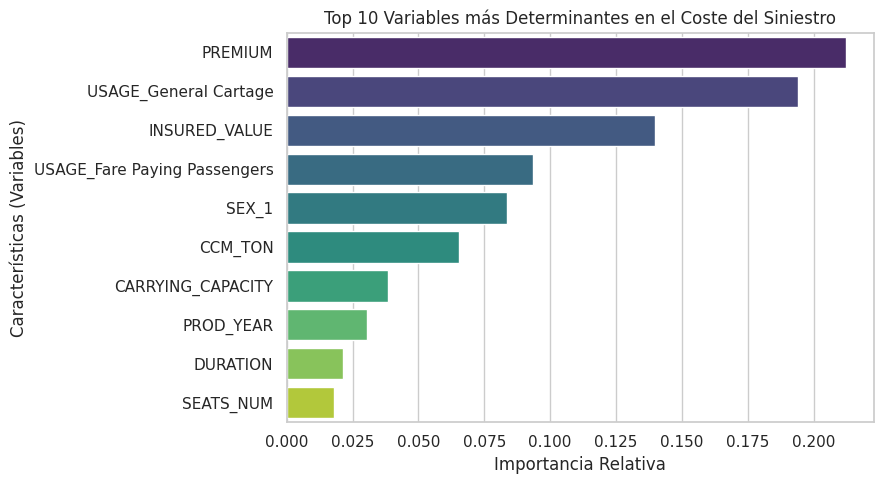

                         Variable  Importancia
1                         PREMIUM     0.212271
200         USAGE_General Cartage     0.193967
0                   INSURED_VALUE     0.139625
199  USAGE_Fare Paying Passengers     0.093507
7                           SEX_1     0.083720
5                         CCM_TON     0.065253
4               CARRYING_CAPACITY     0.038418
2                       PROD_YEAR     0.030480
6                        DURATION     0.021554
3                       SEATS_NUM     0.018068


In [40]:
# 1. Extraemos la importancia de las variables del modelo ajustado
importancias = modelo_rf_ajustado.feature_importances_
nombres_variables = X_train.columns

# 2. Creamos un DataFrame para ordenarlas de mayor a menor
df_importancias = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 3. Nos quedamos con las 10 variables más importantes para no saturar el gráfico
df_top_10 = df_importancias.head(10)

# 4. Pintamos el gráfico de barras
plt.figure(figsize=(9, 5))
sns.barplot(x='Importancia', y='Variable', data=df_top_10, palette='viridis')
plt.title('Top 10 Variables más Determinantes en el Coste del Siniestro')
plt.xlabel('Importancia Relativa')
plt.ylabel('Características (Variables)')
plt.tight_layout()
plt.show()

# Mostramos el top por texto también
print(df_top_10)

In [ ]:
# 1. El modelo predice sobre el examen (en escala logarítmica)
y_pred_log = modelo_rf_ajustado.predict(X_test)

# 2. Pasamos las predicciones y los valores reales a Euros usando np.expm1
y_pred_euros = np.expm1(y_pred_log) 
y_test_euros = np.expm1(y_test)

# 3. Creamos el DataFrame 
comparativa = pd.DataFrame({
    'Real (Euros)': y_test_euros, 
    'Predicción (Euros)': y_pred_euros
})
comparativa['Diferencia'] = abs(comparativa['Real (Euros)'] - comparativa['Predicción (Euros)'])

# 4. Calculamos las métricas comerciales en Euros
mae_euros = comparativa['Diferencia'].mean()
r2_euros = r2_score(comparativa['Real (Euros)'], comparativa['Predicción (Euros)'])

print("=== MÉTRICAS EN EUROS REALES ===")
print(f"Error Medio Absoluto (MAE): {mae_euros:.2f} €")
print(f"R² en escala original de Euros: {r2_euros:.4f}")
print("-" * 45)

# 5. Enfoque de Ranking (MRR y MAP) para el Top 10% de siniestros más caros
umbral_alto_coste = comparativa['Real (Euros)'].quantile(0.90)
comparativa_ranking = comparativa.sort_values(by='Predicción (Euros)', ascending=False).copy()
comparativa_ranking['Es_Caro_Real'] = (comparativa_ranking['Real (Euros)'] >= umbral_alto_coste).astype(int)

def calcular_mrr(relevancias):
    posiciones = np.where(relevancias == 1)[0]
    return 1 / (posiciones[0] + 1) if len(posiciones) > 0 else 0

def calcular_map(relevancias):
    precisiones = []
    aciertos_encontrados = 0
    for i, rel in enumerate(relevancias):
        if rel == 1:
            aciertos_encontrados += 1
            precisiones.append(aciertos_encontrados / (i + 1))
    return np.mean(precisiones) if precisiones else 0

mrr_resultado = calcular_mrr(comparativa_ranking['Es_Caro_Real'].values)
map_resultado = calcular_map(comparativa_ranking['Es_Caro_Real'].values)

print("=== MÉTRICAS DE VALIDACIÓN DE RANKING ===")
print(f"MRR (Mean Reciprocal Rank): {mrr_resultado:.4f}")
print(f"MAP (Mean Average Precision): {map_resultado:.4f}")

=== MÉTRICAS EN EUROS REALES ===
Error Medio Absoluto (MAE): 42338.57 €
R² en escala original de Euros: -0.0852
---------------------------------------------
=== MÉTRICAS DE VALIDACIÓN DE RANKING ===
MRR (Mean Reciprocal Rank): 0.5000
MAP (Mean Average Precision): 0.1928


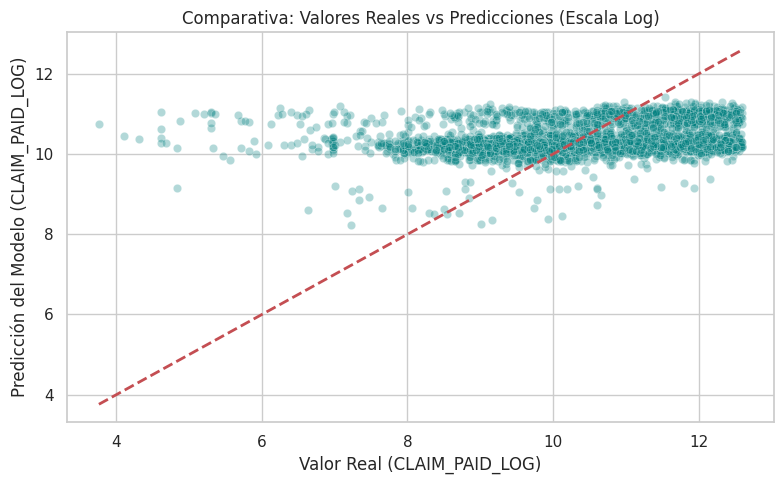

In [43]:
plt.figure(figsize=(8, 5))
# Dibujamos los puntos en escala logarítmica para que se vea mejor la distribución
sns.scatterplot(x=y_test, y=y_pred_test_log2, alpha=0.3, color='teal')
# Línea de referencia ideal (si el modelo fuera perfecto, los puntos irían por aquí)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.title('Comparativa: Valores Reales vs Predicciones (Escala Log)')
plt.xlabel('Valor Real (CLAIM_PAID_LOG)')
plt.ylabel('Predicción del Modelo (CLAIM_PAID_LOG)')
plt.tight_layout()
plt.show()